# Predictive Model 2: 

#### Using Gradient Boosting to measure what variables are associated with errors in forecasted labor. What factors are causing deviations in the forecast?

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#Opening and formating the data
data = pd.read_excel('Mrdak_339Data.xlsx', sheet_name = 'Formatted Data')
#Dropping unnecessary columns
data = data.drop([
'Coffee Actual Sales',
'Actual Sales per Labor Hour.22',
'Actual AHR.22',
'Actual Hours.22',
'Actual % Effective.22',
'Actual Overtime Hours.22',
'Actual Overtime Wages.22',
'Actual Overtime %.22',
'Forecast Fixed Hours.22',
'Forecast Variable Hours.22',
'Earned Hours @ 100%.22',
'Without Fuel Actual Sales',
'Actual Sales per Labor Hour.29',
'Actual AHR.29',
'Actual Hours.29',
'Actual % Effective.29',
'Actual Overtime Hours.29',
'Actual Overtime Wages.29',
'Actual Overtime %.29',
'Forecast Fixed Hours.29',
'Forecast Variable Hours.29',
'Earned Hours @ 100%.29',
'Fuel Actual Sales',
'Actual Sales per Labor Hour.30',
'Actual AHR.30',
'Actual Hours.30',
'Actual % Effective.30',
'Actual Overtime Hours.30',
'Actual Overtime Wages.30',
'Actual Overtime %.30',
'Forecast Fixed Hours.30',
'Forecast Variable Hours.30',
'Earned Hours @ 100%.30',
'Grocery & HBC/GM Actual Sales',
'Actual Sales per Labor Hour.14',
'Actual AHR.14',
'Actual Hours.14',
'Actual % Effective.14',
'Actual Overtime Hours.14',
'Actual Overtime Wages.14',
'Actual Overtime %.14',
'Forecast Fixed Hours.14',
'Forecast Variable Hours.14',
'Earned Hours @ 100%.14'], axis = 1)
#Dropping Average and formatting date
data = data[data['Date'].str.strip() != 'Average']
data["Date"] = pd.to_datetime(data["Date"] + "-1", format = "%G W%V-%u")
data = data.sort_values("Date")

In [4]:
data['week'] = data['Date'].dt.isocalendar().week
data['month'] = data['Date'].dt.month
data['year'] = data['Date'].dt.year

C:\Users\nikol\AppData\Local\Temp\ipykernel_8944\3123566190.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['week'] = data['Date'].dt.isocalendar().week
C:\Users\nikol\AppData\Local\Temp\ipykernel_8944\3123566190.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['month'] = data['Date'].dt.month
C:\Users\nikol\AppData\Local\Temp\ipykernel_8944\3123566190.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

In [5]:
#for col in data.columns:
    #print(col)

In [6]:
#Combining fixed and variable forecast hours as a total forecast hours
data['Forecast Total Hours'] = data['Forecast Fixed Hours.31'] + data['Forecast Variable Hours.31']

C:\Users\nikol\AppData\Local\Temp\ipykernel_8944\1251136497.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Forecast Total Hours'] = data['Forecast Fixed Hours.31'] + data['Forecast Variable Hours.31']


In [7]:
#Creating a variable to measure the forecast error. This will be my target variable
data['Forecast Error'] = data['Actual Hours.31'] - data['Forecast Total Hours']

C:\Users\nikol\AppData\Local\Temp\ipykernel_8944\423621233.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Forecast Error'] = data['Actual Hours.31'] - data['Forecast Total Hours']


In [8]:
data = data.copy()

In [9]:
#Establishing the dependent and independents. Looking at just date, sales and sales per labor hour. My goal is to avoid multicollinearity so I excluded variables like overtime and actual hours.   
X = data[[
        'week',
        'month',
        'year',
        'Grocery Actual Sales',
        'Actual Sales per Labor Hour.3',
        'Dairy Actual Sales',
        'Actual Sales per Labor Hour.4',
        'Frozen Actual Sales',
        'Actual Sales per Labor Hour.5',
        'Liquor Actual Sales',
        'Actual Sales per Labor Hour.6',
        'Natural Foods Actual Sales',
        'Actual Sales per Labor Hour.7',
        'HBC Actual Sales',
        'Actual Sales per Labor Hour.9',
        'Cosmetics Actual Sales',
        'Actual Sales per Labor Hour.10',
        'GM Actual Sales',
        'Actual Sales per Labor Hour.11',
        'Apparel Actual Sales',
        'Actual Sales per Labor Hour.12',
        'Produce Actual Sales',
        'Actual Sales per Labor Hour.15',
        'Floral Actual Sales',
        'Actual Sales per Labor Hour.16',
        'Meat Actual Sales',
        'Actual Sales per Labor Hour.18',
        'Seafood Actual Sales',
        'Actual Sales per Labor Hour.19',
        'Deli Actual Sales',
        'Actual Sales per Labor Hour.21',
        'Bakery Actual Sales',
        'Actual Sales per Labor Hour.24',
        'Rx Actual Sales',
        'Actual Sales per Labor Hour.28'
    ]]
y = data['Forecast Error']

In [11]:
#Setting up the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model3 = GradientBoostingRegressor(n_estimators = 200, learning_rate = 0.05, max_depth = 3, random_state = 42)
# number of trees (like random forest), how much each tree contributes to final prediction, how many branches in each tree
model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)

In [12]:
#Reading the results of the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2:', r2)

MAE: 119.49901873596967
RMSE: 163.6871575923893
R2: 0.42437232642248246


In [14]:
sig_df3 = pd.DataFrame({
    'feature': X.columns,
    'sig': model3.feature_importances_
}).sort_values(by = 'sig', ascending = False)

print(sig_df3.head(15))

                           feature       sig
22  Actual Sales per Labor Hour.15  0.135453
26  Actual Sales per Labor Hour.18  0.112608
13                HBC Actual Sales  0.107458
32  Actual Sales per Labor Hour.24  0.106197
4    Actual Sales per Labor Hour.3  0.079956
0                             week  0.073682
33                 Rx Actual Sales  0.058979
15          Cosmetics Actual Sales  0.047835
31             Bakery Actual Sales  0.036071
9              Liquor Actual Sales  0.034136
29               Deli Actual Sales  0.031943
27            Seafood Actual Sales  0.031879
23             Floral Actual Sales  0.026529
2                             year  0.018669
3             Grocery Actual Sales  0.009608


In [22]:
top5 = sig_df3.head(5).copy()
top5['percent'] = top5['sig'] * 100

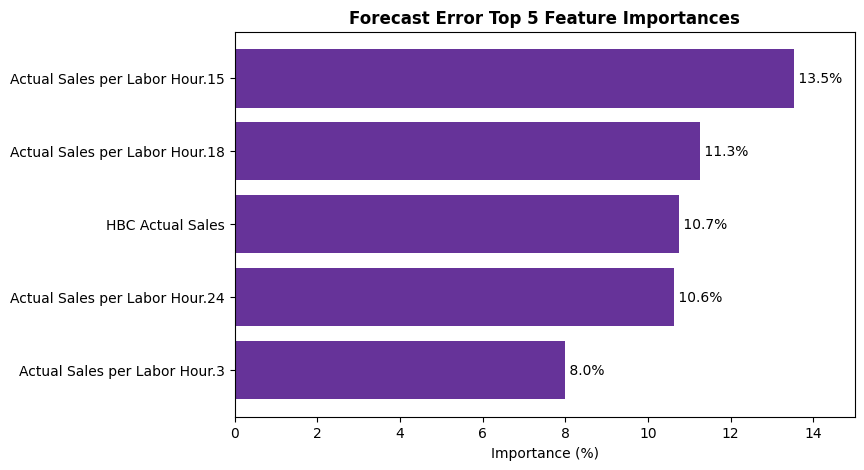

In [24]:
plt.figure(figsize = (8,5))

plt.barh(top5['feature'], top5['percent'], color = 'rebeccapurple')
plt.gca().invert_yaxis()

for i, v in enumerate(top5['percent']):
    plt.text(v, i, f' {v:.1f}%', va = 'center')

plt.xlabel('Importance (%)')
plt.title('Forecast Error Top 5 Feature Importances', fontweight = 'bold')
plt.xlim(0, 15)
plt.show()

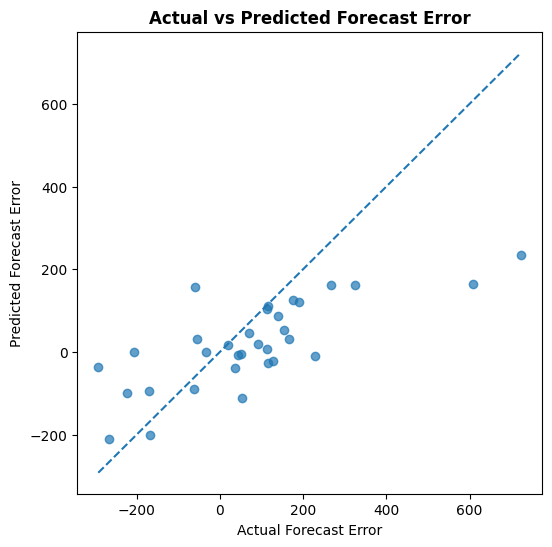

In [19]:
plt.figure(figsize = (6,6))
plt.scatter(y_test, y_pred, alpha = 0.7)

# 45-degree line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle = '--')

plt.xlabel('Actual Forecast Error')
plt.ylabel('Predicted Forecast Error')
plt.title('Actual vs Predicted Forecast Error', fontweight = 'bold')

plt.show()

In [20]:
print((y_test - y_pred).mean())
#A positive mean shows that the actual test values are greater than the prediction values

53.36678891186264


### Analysis

The model has an R2 of .42, which is not extrordinarily high, but yielded improved R2, MAE and RMSE compared to the random forest regression model. The feature significances show that sales per labor hour are much more significant than actual sales in driving errors in the forecast. The discrepencies in forecast are systemic, not random, caused by labor efficiency not total sales volume. The four most significant 'Sales per Labor Hour' variables were Produce, Meat, Bakery, and Grocery. These departments specifically, are labor-intensive. In addtion, the sixth most important feature was week. This indicates potential seasonality that causes error in the labor forecast as well. 